In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("loanapprove.csv")

In [3]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
#Step 1:Handling missing values(null values)..sklearn.impute import SimpleInputer..
# for categorical values replace null with most frequent value
#for numerical values replace null with the mean 
num_col=df.select_dtypes(include=["number"]).columns

In [7]:
cat_col=df.select_dtypes(include=["object"]).columns

In [8]:
from sklearn.impute import SimpleImputer

In [9]:
numimp=SimpleImputer(strategy="mean")

In [10]:
df[num_col]=numimp.fit_transform(df[num_col])

In [11]:
catimp=SimpleImputer(strategy="most_frequent")

In [12]:
df[cat_col]=catimp.fit_transform(df[cat_col])

In [13]:
#EDA 
classes_count=df["Loan_Approved"].value_counts()

([<matplotlib.patches.Wedge at 0x2119b534f10>,
 [Text(-0.6521425632196803, 0.8858386293435534, 'Yes'),
  Text(0.6521426461578755, -0.8858385682855563, 'No')],
 [Text(-0.35571412539255287, 0.4831847069146654, '70.2%'),
  Text(0.3557141706315684, -0.4831846736103034, '29.8%')])

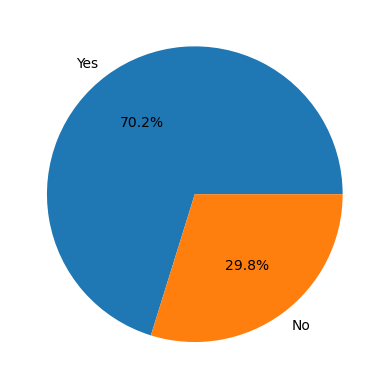

In [14]:
plt.pie(classes_count,labels=["Yes","No"],autopct="%1.1f%%")

In [15]:
gender_count=df["Gender"].value_counts()

([<matplotlib.patches.Wedge at 0x2119b5a7410>,
 [Text(-0.40814805524733594, 1.021476952749213, 'Male'),
  Text(0.4081480552473354, -1.0214769527492131, 'Female')],
 [Text(-0.22262621195309232, 0.5571692469541161, '62.1%'),
  Text(0.222626211953092, -0.5571692469541162, '37.9%')])

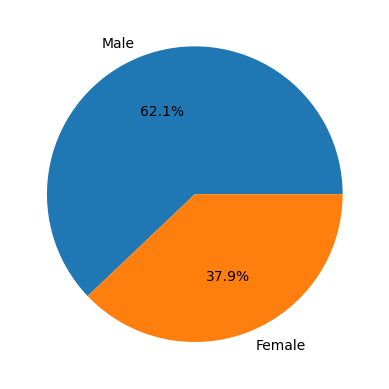

In [16]:
plt.pie(gender_count,labels=["Male","Female"],autopct="%1.1f%%")

<Axes: xlabel='Gender'>

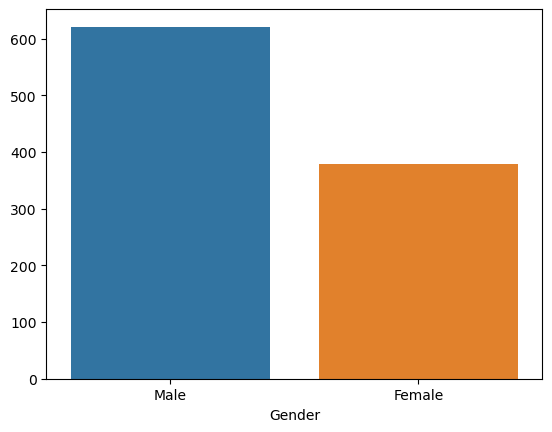

In [17]:
sns.barplot(x=gender_count.index,y=gender_count.values)

C:\Users\KIIT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Applicant_Income', ylabel='Count'>

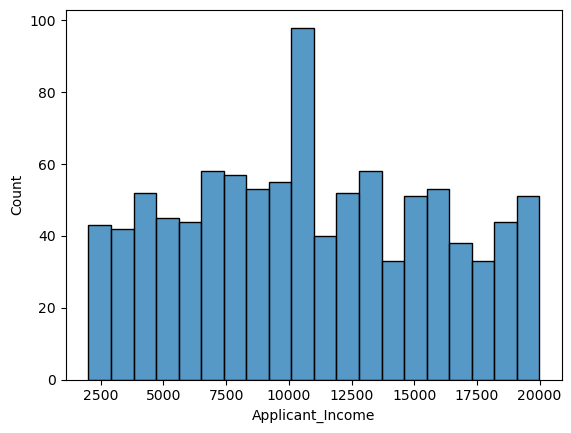

In [18]:
sns.histplot(data=df,x="Applicant_Income",bins=20)

C:\Users\KIIT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

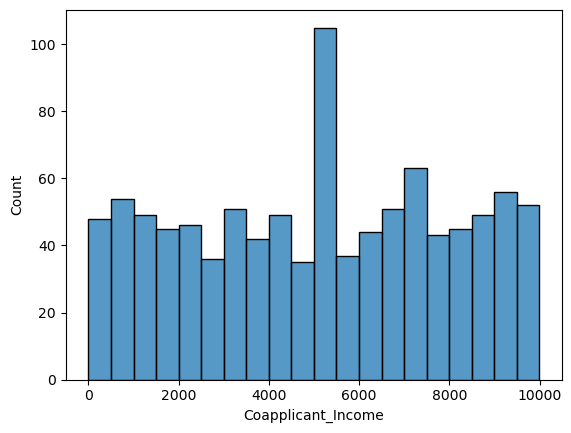

In [19]:
sns.histplot(data=df,x="Coapplicant_Income",bins=20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

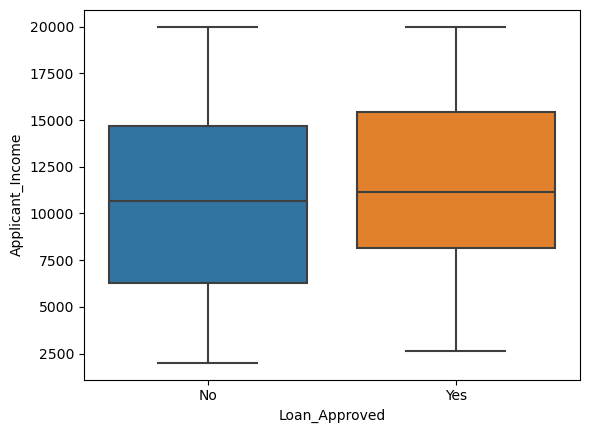

In [20]:
sns.boxplot(data=df,x="Loan_Approved",y="Applicant_Income")

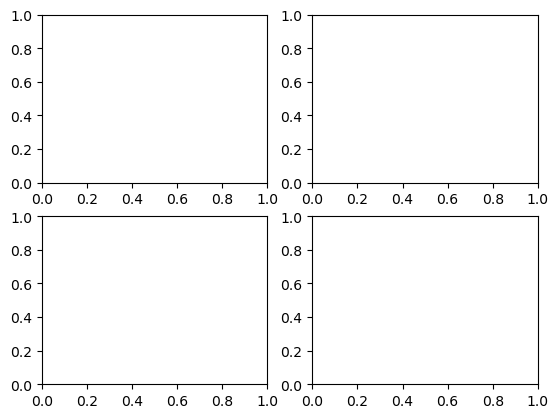

In [21]:
fig,axes=plt.subplots(2,2)

In [22]:
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

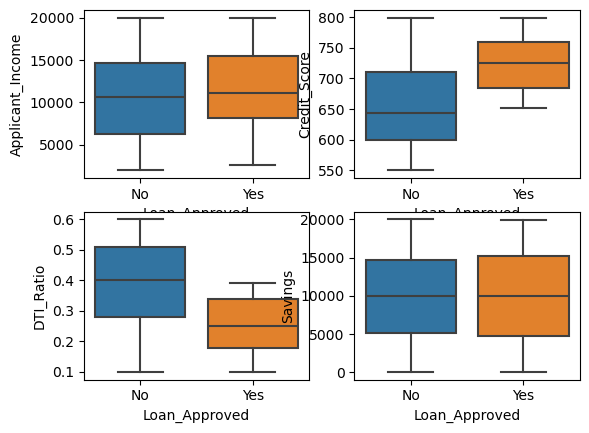

In [23]:

fig,axes=plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")

In [24]:
#Encoding of Categorical Data (Label Encoder and OneHotEncoder )
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [25]:
le=LabelEncoder()

In [26]:
df["Education_Level"]=le.fit_transform(df["Education_Level"])

In [27]:
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [28]:
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

In [29]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

In [30]:
encoded=ohe.fit_transform(df[cols])

In [31]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

In [32]:
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [33]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

In [35]:
#train_test_split
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
#standardising xtrain and xtest
from sklearn.preprocessing import StandardScaler

In [38]:
scaler=StandardScaler()

In [39]:
x_train_scaled=scaler.fit_transform(x_train)

In [41]:
x_test_scaled=scaler.transform(x_test)

In [42]:
#logistic regression
from sklearn.linear_model import LogisticRegression

In [43]:
lr=LogisticRegression()

In [44]:
lr.fit(x_train_scaled,y_train)

LogisticRegression()

In [46]:
y_pred=lr.predict(x_test_scaled)

In [47]:
#evaluation of the model
from sklearn.metrics import precision_score,accuracy_score,recall_score

In [50]:
print(precision_score(y_test,y_pred))

0.7868852459016393


In [62]:
from sklearn.naive_bayes import GaussianNB

In [63]:
nb=GaussianNB()

In [64]:
nb.fit(x_train_scaled,y_train)

GaussianNB()

In [67]:
y_pred=nb.predict(x_test_scaled)

In [70]:
from sklearn.metrics import precision_score

In [71]:
print(precision_score(y_test,y_pred))

0.8035714285714286
